# 00 · Data provenance and basketball exploration

**NCAA tournament probability forecasting** · Begin here

This is the current entry point. We predict the probability that the lower-ID team wins each men's or women's NCAA matchup. Kaggle evaluates probabilities using **Brier score**; lower is better.

The reproducible sequence is **00 → 01 → 02**: verify and explore data, inspect time boundaries, then assess features. Python modules own the computation, so a completed command-line run is reusable without rerunning the earlier notebooks. Each notebook also renders the recorded, checksum-verified evidence in a fresh clone.

[Official competition and metric](https://www.kaggle.com/competitions/march-machine-learning-mania-2026) · [Studio workflow](../docs/studio.md)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from march_mania.notebook_support import review_source, table, style

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Open from the project directory"
CONFIG = json.loads((ROOT / "configs/feature_store.json").read_text())
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white", "axes.titleweight": "bold"})
style()


## Confirm the data exists

If the official raw files are present, this cell audits them and reuses matching completed checkpoints. It does not authenticate or download again. In a fresh GitHub clone, it displays the recorded audit and clearly labels that source.

For a new runtime, `march-data --output data/kaggle` downloads the official files. The Studio guide includes private S3 mirroring. No credentials belong in this notebook.

In [2]:
from march_mania.data_review import run
RAW = ROOT / "data/kaggle/raw"
if RAW.is_dir() and any(RAW.glob("*.csv")):
    run(RAW, ROOT / "outputs/data_review", CONFIG)
REVIEW, SUMMARY, SOURCE = review_source(ROOT, "data_review")
assert REVIEW is not None, "Run march-audit after march-data to produce the audit"
display(Markdown(f"**Evidence:** {SOURCE}. **Files:** {SUMMARY['files']}. "
                 f"**Download recorded:** {SUMMARY.get('download_recorded_at')}. "
                 f"**Download hashes verified:** {SUMMARY['download_hashes_verified']}."))
INVENTORY = pd.read_csv(REVIEW / "inventory.csv")
SEASONS = pd.read_csv(REVIEW / "seasons.csv")
table(INVENTORY[["file", "rows", "columns", "bytes", "first_season", "last_season", "missing_cells", "feature_source"]])

**Evidence:** recorded Git evidence (checksums verified). **Files:** 35. **Download recorded:** 2026-09-07T00:09:59.084292+00:00. **Download hashes verified:** True.

file,rows,columns,bytes,first_season,last_season,missing_cells,feature_source
Cities.csv,510,3,9788,NaN,NaN,0,False
Conferences.csv,51,2,1643,NaN,NaN,0,False
MConferenceTourneyGames.csv,7093,5,186863,2001.000000,2026.000000,0,False
MGameCities.csv,92438,6,2980361,2010.000000,2026.000000,0,False
MMasseyOrdinals.csv,5865001,5,129133178,2003.000000,2026.000000,0,True
MNCAATourneyCompactResults.csv,2585,8,77711,1985.000000,2025.000000,0,True
MNCAATourneyDetailedResults.csv,1449,34,144875,2003.000000,2025.000000,0,False
MNCAATourneySeedRoundSlots.csv,776,5,15904,NaN,NaN,0,False
MNCAATourneySeeds.csv,2694,3,40570,1985.000000,2026.000000,0,True
MNCAATourneySlots.csv,2653,4,53052,1985.000000,2026.000000,0,False


## What can the data support?

Compact results provide scores, dates, opponents, venues and overtime. Detailed results add shooting, rebounding, turnovers, assists, steals, blocks and fouls. Massey supplies **men's** ranking publications; there is no equivalent women's ranking file in this snapshot. Coaches and conferences are contextual sources for later research. Player minutes, lineups and injury availability are absent, so this pipeline cannot honestly produce those features.

Reference tables and historical tournament results are inventoried for provenance. Feature construction restricts current-season results to regular-season DayNum ≤132. NCAA labels are kept separate.

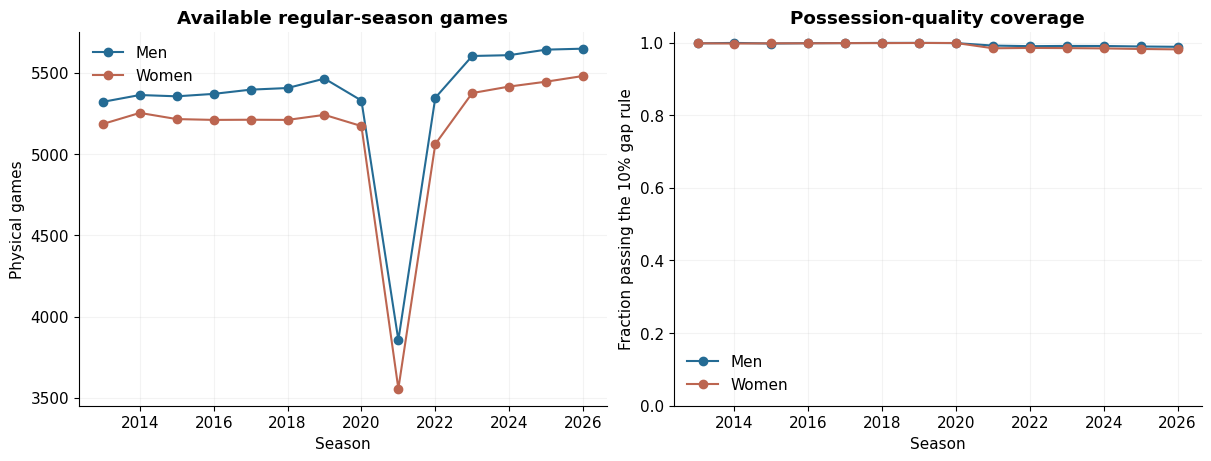

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for gender, color, label in [("M", "#246b94", "Men"), ("W", "#bc6550", "Women")]:
    panel = SEASONS.loc[SEASONS.Gender.eq(gender)]
    axes[0].plot(panel.Season, panel.regular_games, marker="o", color=color, label=label)
    axes[1].plot(panel.Season, panel.clean_possession_fraction, marker="o", color=color, label=label)
axes[0].set(title="Available regular-season games", xlabel="Season", ylabel="Physical games")
axes[1].set(title="Possession-quality coverage", xlabel="Season", ylabel="Fraction passing the 10% gap rule", ylim=(0, 1.03))
for ax in axes:
    ax.grid(alpha=.15)
    ax.legend(frameon=False)
plt.show()

## Pace and shot selection change over time

These plots use regular-season box scores only. Changes in pace and three-point frequency motivate possession-normalized rates, shooting uncertainty and chronological validation. The short 2021 season makes unshrunk counts especially fragile. The 2020 regular season is displayed for context; its canceled NCAA tournament contributes no validation labels.

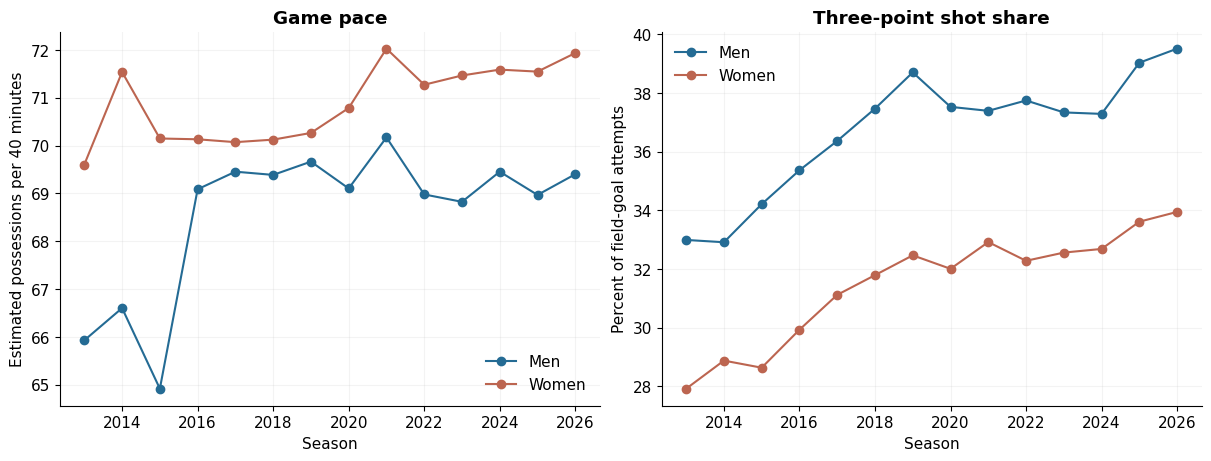

Gender,Season,teams,regular_games,detailed_games,latest_regular_day,neutral_game_fraction,overtime_fraction
M,2013,347,5320,5320,132,0.102820,0.059398
M,2021,347,3855,3855,132,0.105318,0.055253
M,2026,365,5647,5647,132,0.111387,0.055959
W,2013,345,5184,5184,132,0.114583,0.042052
W,2021,343,3556,3556,132,0.075647,0.045557
W,2026,363,5479,5479,132,0.094908,0.045081


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for gender, color, label in [("M", "#246b94", "Men"), ("W", "#bc6550", "Women")]:
    panel = SEASONS.loc[SEASONS.Gender.eq(gender)]
    axes[0].plot(panel.Season, panel.mean_tempo, marker="o", color=color, label=label)
    axes[1].plot(panel.Season, 100 * panel.three_attempt_share, marker="o", color=color, label=label)
axes[0].set(title="Game pace", xlabel="Season", ylabel="Estimated possessions per 40 minutes")
axes[1].set(title="Three-point shot share", xlabel="Season", ylabel="Percent of field-goal attempts")
for ax in axes:
    ax.grid(alpha=.15)
    ax.legend(frameon=False)
plt.show()
table(SEASONS.query("Season in [2013, 2021, 2026]")[["Gender", "Season", "teams", "regular_games", "detailed_games", "latest_regular_day", "neutral_game_fraction", "overtime_fraction"]])

## Continue to notebook 01

Open `01_split_protocol_and_pre_tournament_snapshots.ipynb` and choose **Run All**. It reads the same audit and shows exactly which seasons train and validate each experiment. Hash-matching downloads and audit tasks are reused after interruption; changed inputs create a separate fingerprinted run.